In [1]:
import matplotlib.pyplot as plt

In [16]:
# Jupyter cell: regenerate conversations, strip prefixes, and save/load in HF-friendly format
# HF Datasets expects ONE OBJECT per line. We'll write: {"messages": [ {role, content, thinking}, ... ]}

import json, math, re
from pathlib import Path
from typing import List, Dict, Any
import pandas as pd
from datasets import load_dataset

# ----- Config -----
INPUT_CSV = "eurorad_train.csv"
OUTPUT_PATH = Path("eurorad_train_messages.jsonl")  # HF-friendly JSONL: {"messages": [...]} per line
OUTPUT_FORMAT = "jsonl"  # "jsonl" or "json"

SYSTEM_PROMPT = (
    "You are a careful radiology diagnosis selector.\n"
    "Given a case description and a finite list of candidate diagnoses, "
    "select the single most likely final diagnosis FROM THE LIST.\n"
    "Response rules:\n"
    "1) Output EXACTLY one option, copied VERBATIM from the list.\n"
    "2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n"
    "3) If uncertain, choose the closest match from the list. Never invent new options."
)

USER_TEMPLATE = (
    "{case_text}\n\n"
    "Candidate diagnoses (choose ONE):\n{options_block}\n\n"
    "Return exactly one option from the list above, copied verbatim."
)

def dedup_options(s: str) -> List[str]:
    opts = [o.strip() for o in (s or "").split(",") if o.strip()]
    out, seen = [], set()
    for o in opts:
        if o not in seen:
            seen.add(o)
            out.append(o)
    return out

def pick_description(row: pd.Series) -> str:
    desc = (row.get("PostDescription") or row.get("OriginalDescription") or "").strip()
    desc = "\n".join(line.rstrip() for line in desc.splitlines()).strip()
    # Remove leading "Case description:" or "Clinical History:" if present
    desc = re.sub(r"^\s*(Case description:|Clinical History:)\s*", "", desc, flags=re.IGNORECASE)
    return desc

def build_user_content(row: pd.Series) -> str:
    desc = pick_description(row)
    options = dedup_options(row.get("DifferentialDiagnosisList", ""))
    opts_block = "\n".join(f"- {o}" for o in options) if options else "- (no options provided)"
    return USER_TEMPLATE.format(case_text=desc, options_block=opts_block)

def row_to_messages(row: pd.Series) -> List[Dict[str, Any]]:
    # Return a list of message dicts; "thinking" stays null (None in Python)
    return [
        {"role": "system", "content": SYSTEM_PROMPT, "thinking": None},
        {"role": "user", "content": build_user_content(row), "thinking": None},
        {"role": "assistant", "content": str(row.get("FinalDiagnosis", "")).strip(), "thinking": None},
    ]

def to_json_serializable(x):
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return None
    return x

# ----- Load CSV -----
df = pd.read_csv(INPUT_CSV, dtype=str, keep_default_na=False)

# Ensure case_id exists if needed (not used in prompt, but useful for traceability)
if "case_id" not in df.columns:
    df["case_id"] = df.index.astype(str)

# Build messages
rows_as_messages = [row_to_messages(row) for _, row in df.iterrows()]

# ----- Write in HF-friendly shape -----
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
if OUTPUT_FORMAT == "jsonl" or OUTPUT_PATH.suffix.lower() == ".jsonl":
    with OUTPUT_PATH.open("w", encoding="utf-8") as f:
        for msgs in rows_as_messages:
            f.write(json.dumps({"messages": msgs}, ensure_ascii=False, default=to_json_serializable) + "\n")
else:
    # JSON array file of {"messages": [...]}
    with OUTPUT_PATH.open("w", encoding="utf-8") as f:
        json.dump([{"messages": m} for m in rows_as_messages],
                  f, ensure_ascii=False, indent=2, default=to_json_serializable)

print(f"Wrote {len(rows_as_messages)} examples -> {OUTPUT_PATH}")

Wrote 1895 examples -> eurorad_train_messages.jsonl


In [17]:
# ----- Load back with HF datasets (verifies format) -----
ds = load_dataset("json", data_files=str(OUTPUT_PATH))["train"]
print(ds)

# Preview first example (as dict)
ex0 = ds[0]
print(json.dumps(ex0, ensure_ascii=False, indent=2)[:1000])

# Quick sanity checks
assert "messages" in ex0 and isinstance(ex0["messages"], list) and len(ex0["messages"]) >= 3
assert ex0["messages"][0]["role"] == "system"
assert ex0["messages"][1]["role"] == "user"
assert ex0["messages"][-1]["role"] == "assistant"

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 1895
})
{
  "messages": [
    {
      "role": "system",
      "content": "You are a careful radiology diagnosis selector.\nGiven a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\nResponse rules:\n1) Output EXACTLY one option, copied VERBATIM from the list.\n2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n3) If uncertain, choose the closest match from the list. Never invent new options.",
      "thinking": null
    },
    {
      "role": "user",
      "content": "This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having \"heard a loud crack\" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.\n\n Imaging Findings: The outpatient radiograph was ini

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-20b")

In [8]:
import torch
from transformers import AutoModelForCausalLM, Mxfp4Config

quantization_config = Mxfp4Config(dequantize=True)
model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    quantization_config=quantization_config,
    use_cache=False,
    device_map="auto",
)

model = AutoModelForCausalLM.from_pretrained("openai/gpt-oss-20b", **model_kwargs)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
messages = [
    {"role": "user", "content": "This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having \"heard a loud crack\" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.\n\n Imaging Findings: The outpatient radiograph was initially assessed as normal. Although indeed not demonstrating any femoral or pelvic fracture, it did in fact show focal cortical thickening of the left lateral proximal femur. At this site, one week later, a complete transverse fracture of the proximal femur was seen with some displacement, with features consistent with atypical femoral fracture.\n\nCandidate diagnoses (choose ONE):\n- Insufficiency fracture\n- Pathological fracture\n- Bisphosphonate-associated atypical femoral fracture with preceding cortical reaction\n\nReturn exactly one option from the list above, copied verbatim."},
]

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt",
).to(model.device)

output_ids = model.generate(input_ids, max_new_tokens=512)
response = tokenizer.batch_decode(output_ids)[0]
print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-02

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having "heard a loud crack" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.

 Imaging Findings: The outpatient radiograph was initially assessed as normal. Although indeed not demonstrating any femoral or pelvic fracture, it did in fact show focal cortical thickening of the left lateral proximal femur. At this site, one week later, a complete transverse fracture of the proximal femur was seen with some displacement, with features consistent with atypical femoral fracture.

C

In [10]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules="all-linear",
    target_parameters=[
        "7.mlp.experts.gate_up_proj",
        "7.mlp.experts.down_proj",
        "15.mlp.experts.gate_up_proj",
        "15.mlp.experts.down_proj",
        "23.mlp.experts.gate_up_proj",
        "23.mlp.experts.down_proj",
    ],
)
peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()

trainable params: 15,040,512 || all params: 20,929,797,696 || trainable%: 0.0719


/home/sagemaker-user/.conda/envs/oss/lib/python3.12/site-packages/peft/tuners/lora/layer.py:159: UserWarning: Unsupported layer type '<class 'transformers.models.gpt_oss.modeling_gpt_oss.GptOssExperts'>' encountered, proceed at your own risk.
  warnings.warn(


In [12]:
from trl import SFTConfig

training_args = SFTConfig(
    learning_rate=2e-4,
    gradient_checkpointing=True,
    num_train_epochs=1,
    logging_steps=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    max_length=2048,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine_with_min_lr",
    lr_scheduler_kwargs={"min_lr_rate": 0.1},
    output_dir="gpt-oss-20b-eurorad-v1",
    report_to="trackio",
    push_to_hub=True,
)

In [ ]:
### from trl import SFTTrainer

# Build trainer
trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=ds,
    processing_class=tokenizer,
)

trainer.train()

# Custom

In [19]:
print("hello")

hello


In [22]:
%matplotlib inline

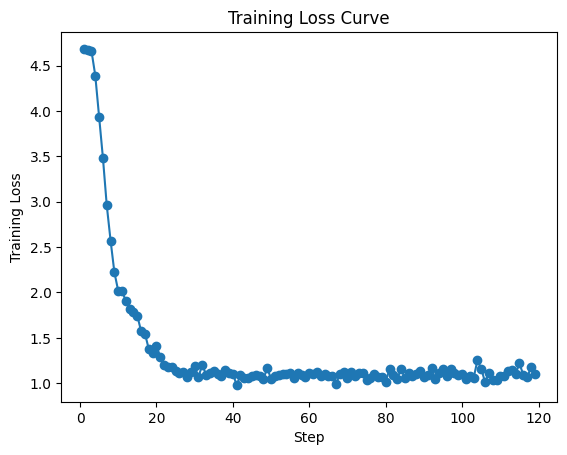

In [23]:
# !pip install matplotlib --quiet
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = [entry["step"] for entry in logs if "loss" in entry]
losses = [entry["loss"] for entry in logs if "loss" in entry]

plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()


In [24]:
trainer.save_model(training_args.output_dir)
trainer.push_to_hub(dataset_name="alif-munim/eurorad-v1")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...ss-20b-eurorad-v1/training_args.bin: 100%|##########| 6.16kB / 6.16kB            

  ...urorad-v1/adapter_model.safetensors:  84%|########3 | 50.3MB / 60.2MB            

  ...t-oss-20b-eurorad-v1/tokenizer.json: 100%|##########| 27.9MB / 27.9MB            

...

New Data Upload                         : |          |  0.00B /  0.00B            

  ...ss-20b-eurorad-v1/training_args.bin: 100%|##########| 6.16kB / 6.16kB            

  ...t-oss-20b-eurorad-v1/tokenizer.json: 100%|##########| 27.9MB / 27.9MB            

  ...urorad-v1/adapter_model.safetensors:  84%|########3 | 50.3MB / 60.2MB            

CommitInfo(commit_url='https://huggingface.co/alif-munim/gpt-oss-20b-eurorad-v1/commit/c2892ce3e0a8a06fb7e97cea7910e1f790dfd06a', commit_message='End of training', commit_description='', oid='c2892ce3e0a8a06fb7e97cea7910e1f790dfd06a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/alif-munim/gpt-oss-20b-eurorad-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='alif-munim/gpt-oss-20b-eurorad-v1'), pr_revision=None, pr_num=None)